# Apple Stock Price Prediction Using an LSTM-Based Recurrent Neural Network

## Introduction

This KIE4031 Machine Learning final summative assessment predicts Apple's next-day closing stock price using historical stock price data. The main stock ticker used in this project is **AAPL**, and the data is collected from Yahoo Finance using the `yfinance` library.

Stock price prediction is difficult because financial markets are influenced by many external factors, including company news, earnings reports, macroeconomic conditions, interest rates, investor sentiment, and unexpected global events. Historical prices can help identify trends, but they cannot fully explain future market movements.

This project uses a Long Short-Term Memory (LSTM) model, which is a Recurrent Neural Network (RNN)-based approach suitable for sequential and time-dependent data. The notebook is an educational time-series forecasting study and should not be treated as a real trading system.

## 1. Library Setup

The required libraries are listed in `requirements.txt`. If any package is missing, install the dependencies using:

```bash
pip install -r requirements.txt
```

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

YFINANCE_CACHE_DIR = Path(".yfinance_cache")
YFINANCE_CACHE_DIR.mkdir(exist_ok=True)
yf.set_tz_cache_location(str(YFINANCE_CACHE_DIR))

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Data Collection

Apple historical stock data is downloaded from Yahoo Finance. The requested study period is from `2015-01-01` to `2025-12-31`. Because `yfinance` treats the end date as exclusive, the download request uses `2026-01-01` so the final trading day of 2025 is included. The downloaded dataset is saved as `AAPL_stock_data.csv` so the notebook can still run if a fresh download is temporarily unavailable.

In [2]:
ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2026-01-01"  # yfinance end date is exclusive; this includes 2025-12-31.
csv_path = Path("AAPL_stock_data.csv")

try:
    data = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)
except Exception as error:
    print(f"Yahoo Finance download failed: {error}")
    data = pd.DataFrame()

if data.empty and csv_path.exists():
    print("Using cached AAPL_stock_data.csv because a fresh Yahoo Finance download was not available.")
    data = pd.read_csv(csv_path, parse_dates=["Date"], index_col="Date")
elif data.empty:
    raise RuntimeError("No AAPL data was downloaded and no cached AAPL_stock_data.csv file was found.")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = [column[0] for column in data.columns]

data = data.sort_index()
data.to_csv(csv_path, index_label="Date")

print("Dataset saved as AAPL_stock_data.csv")
print("Dataset shape:", data.shape)
print("Column names:", list(data.columns))

display(data.head())
display(data.tail())
display(data.describe())

Dataset saved as AAPL_stock_data.csv
Dataset shape: (2766, 6)
Column names: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,24.192610,27.332500,27.860001,26.837500,27.847500,212818400
2015-01-05,23.511061,26.562500,27.162500,26.352501,27.072500,257142000
2015-01-06,23.513279,26.565001,26.857500,26.157499,26.635000,263188400
2015-01-07,23.842985,26.937500,27.049999,26.674999,26.799999,160423600
2015-01-08,24.759089,27.972500,28.037500,27.174999,27.307501,237458000


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-12-24,273.302216,273.809998,275.429993,272.200012,272.339996,17910600
2025-12-26,272.893005,273.399994,275.369995,272.859985,274.160004,21521800
2025-12-29,273.252350,273.760010,274.359985,272.350006,272.690002,23715200
2025-12-30,272.573547,273.079987,274.079987,272.279999,272.809998,22139600
2025-12-31,271.355835,271.859985,273.679993,271.750000,273.059998,27293600


,Adj Close,Close,High,Low,Open,Volume
count,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2.766000e+03
mean,106.127485,108.644931,109.721494,107.462519,108.546994,1.113994e+08
std,74.183369,73.856228,74.561122,73.072339,73.777601,6.804243e+07
min,20.565866,22.584999,22.917500,22.367500,22.500000,1.791060e+07
25%,36.583483,39.080626,39.460626,38.765626,39.160000,6.488962e+07
50%,88.307220,91.204998,92.407501,90.283749,91.176250,9.454380e+07
75%,168.334442,170.830006,172.634998,169.352497,170.955002,1.372937e+08
max,285.659271,286.190002,288.619995,283.299988,286.200012,6.488252e+08


## 3. Data Cleaning

The cleaning process checks for missing values and duplicate rows, removes them if present, and sorts the data chronologically by date. This is important because time-series models depend on the correct order of observations.

In [3]:
print("Missing values before cleaning:")
display(data.isna().sum().to_frame("Missing Values"))

duplicate_rows = data.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

if duplicate_rows > 0:
    data = data.drop_duplicates()
    print("Duplicate rows were dropped.")
else:
    print("No duplicate rows found.")

data = data.dropna().sort_index()
data.index = pd.to_datetime(data.index)
data.index.name = "Date"

print("Missing values after cleaning:")
display(data.isna().sum().to_frame("Missing Values"))
print("Cleaned dataset shape:", data.shape)

Missing values before cleaning:
Number of duplicate rows: 0
No duplicate rows found.
Missing values after cleaning:
Cleaned dataset shape: (2766, 6)


,Missing Values
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


,Missing Values
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


## 4. Exploratory Data Visualization

The following graphs show Apple's closing price trend, trading volume, and moving averages. These plots help provide an initial understanding of the stock's historical movement before model training.

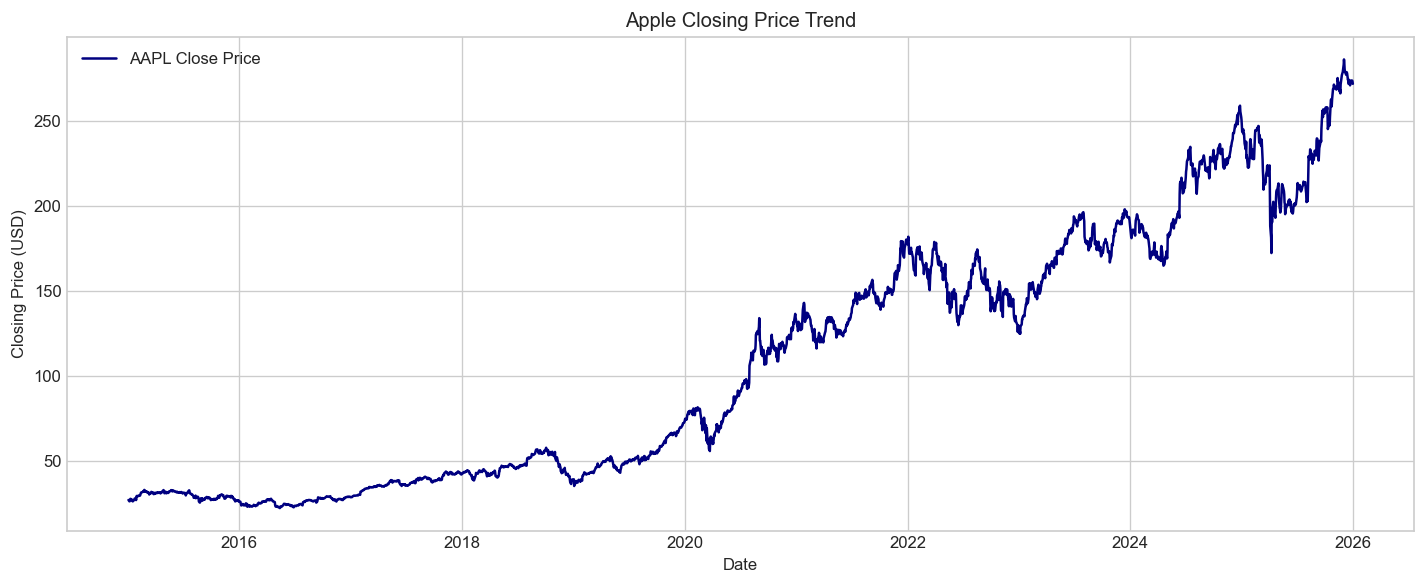

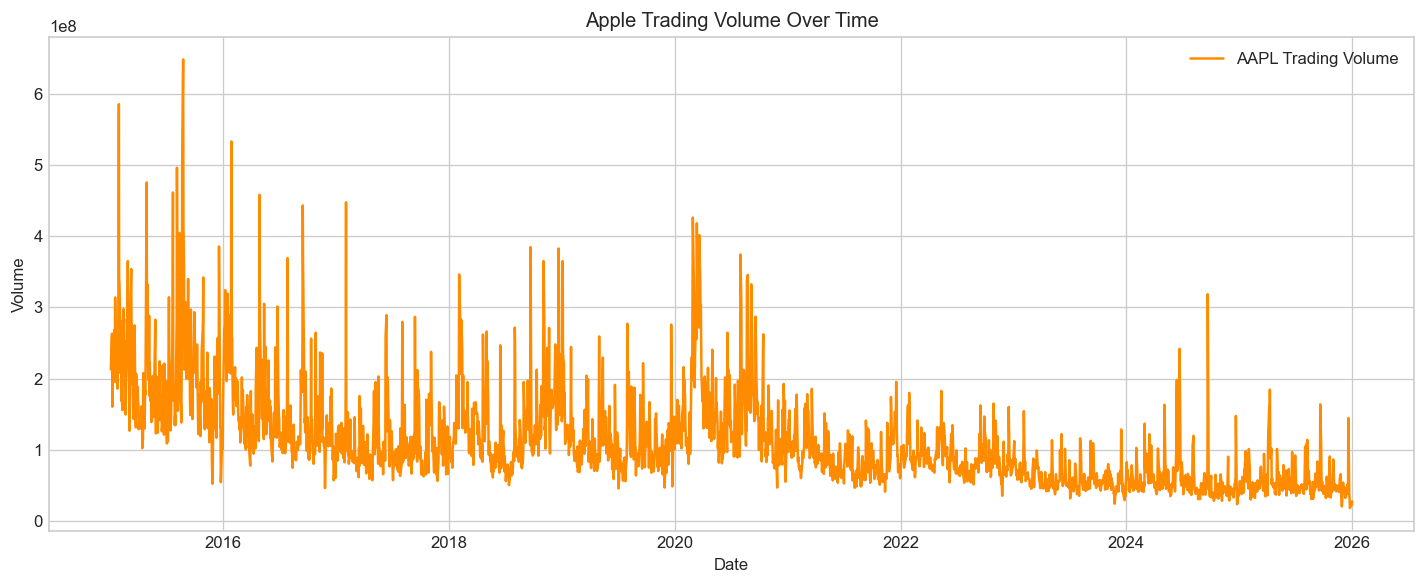

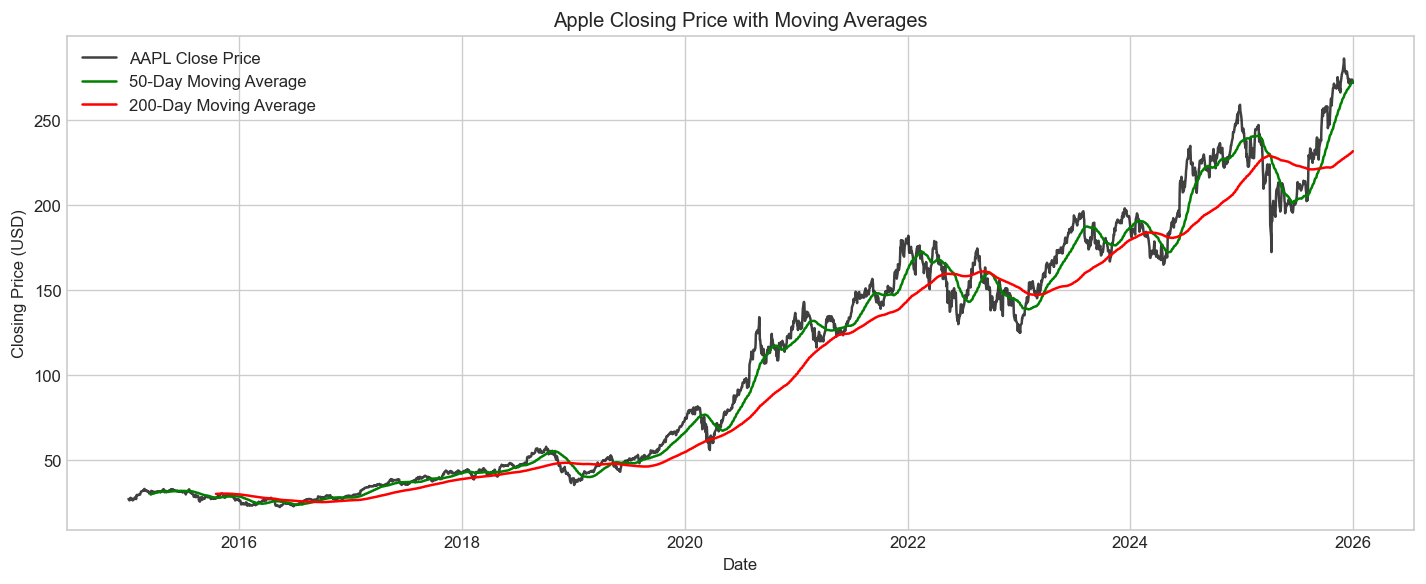

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"], label="AAPL Close Price", color="navy")
plt.title("Apple Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_01_close_price_trend.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Volume"], label="AAPL Trading Volume", color="darkorange")
plt.title("Apple Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_02_volume_trend.png", dpi=150)
plt.show()

data["MA_50"] = data["Close"].rolling(window=50).mean()
data["MA_200"] = data["Close"].rolling(window=200).mean()

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"], label="AAPL Close Price", color="black", alpha=0.75)
plt.plot(data.index, data["MA_50"], label="50-Day Moving Average", color="green")
plt.plot(data.index, data["MA_200"], label="200-Day Moving Average", color="red")
plt.title("Apple Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_03_moving_averages.png", dpi=150)
plt.show()

## 5. Feature Selection

The `Close` price is used as the main prediction target. Using only closing price keeps the model simple and easy to understand for a university assessment. However, it also limits prediction performance because other useful factors such as volume, technical indicators, financial news, and macroeconomic variables are not included.

In [5]:
close_prices = data[["Close"]].copy()
display(close_prices.head())
print("Closing-price data shape:", close_prices.shape)

Closing-price data shape: (2766, 1)


,Close
Date,
2015-01-02,27.332500
2015-01-05,26.562500
2015-01-06,26.565001
2015-01-07,26.937500
2015-01-08,27.972500


## 6. Train-Test Split and Normalization

The data is split chronologically into 80% training data and 20% testing data. The time-series data is not shuffled. To avoid data leakage, `MinMaxScaler` is fitted only on the training closing-price data, and the fitted scaler is then used to transform both training and testing data.

In [6]:
train_size_raw = int(len(close_prices) * 0.8)

train_close = close_prices.iloc[:train_size_raw]
test_close = close_prices.iloc[train_size_raw:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_close)
test_scaled = scaler.transform(test_close)

print("Training data period:", train_close.index.min().date(), "to", train_close.index.max().date())
print("Testing data period:", test_close.index.min().date(), "to", test_close.index.max().date())
print("Training data shape:", train_close.shape)
print("Testing data shape:", test_close.shape)

Training data period: 2015-01-02 to 2023-10-16
Testing data period: 2023-10-17 to 2025-12-31
Training data shape: (2212, 1)
Testing data shape: (554, 1)


## 7. Sequence Preparation

A 60-day lookback window means that each input sample contains the previous 60 trading days of normalized closing prices. The target value is the next day's normalized closing price. The LSTM input is reshaped into `(samples, timesteps, features)`.

In [7]:
lookback = 60


def create_sequences(values, lookback_window):
    X, y = [], []
    for i in range(lookback_window, len(values)):
        X.append(values[i - lookback_window:i, 0])
        y.append(values[i, 0])
    return np.array(X), np.array(y)


combined_scaled = np.vstack([train_scaled, test_scaled])
X_all, y_all = create_sequences(combined_scaled, lookback)
sequence_dates = close_prices.index[lookback:]

train_sequence_count = train_size_raw - lookback
X_train = X_all[:train_sequence_count]
y_train = y_all[:train_sequence_count]
X_test = X_all[train_sequence_count:]
y_test = y_all[train_sequence_count:]

train_dates = sequence_dates[:train_sequence_count]
test_dates = sequence_dates[train_sequence_count:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Training sequence period:", train_dates.min().date(), "to", train_dates.max().date())
print("Testing sequence period:", test_dates.min().date(), "to", test_dates.max().date())

X_train shape: (2152, 60, 1)
y_train shape: (2152,)
X_test shape: (554, 60, 1)
y_test shape: (554,)
Training sequence period: 2015-03-31 to 2023-10-16
Testing sequence period: 2023-10-17 to 2025-12-31


## 8. LSTM Model Development

The model uses two LSTM layers with dropout regularization. The first LSTM layer returns sequences so the second LSTM layer can continue processing the time-dependent representation.

In [8]:
lstm_model = Sequential([
    Input(shape=(lookback, 1)),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50),
    Dropout(0.2),
    Dense(units=1)
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")
lstm_model.summary()

Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴─────────────────────

## 9. Model Training

The LSTM model is trained for 30 epochs with a batch size of 32. A validation split of 10% is taken from the training data. The data is not shuffled because this is a time-series problem.

Final training loss: 0.001831
Final validation loss: 0.003583


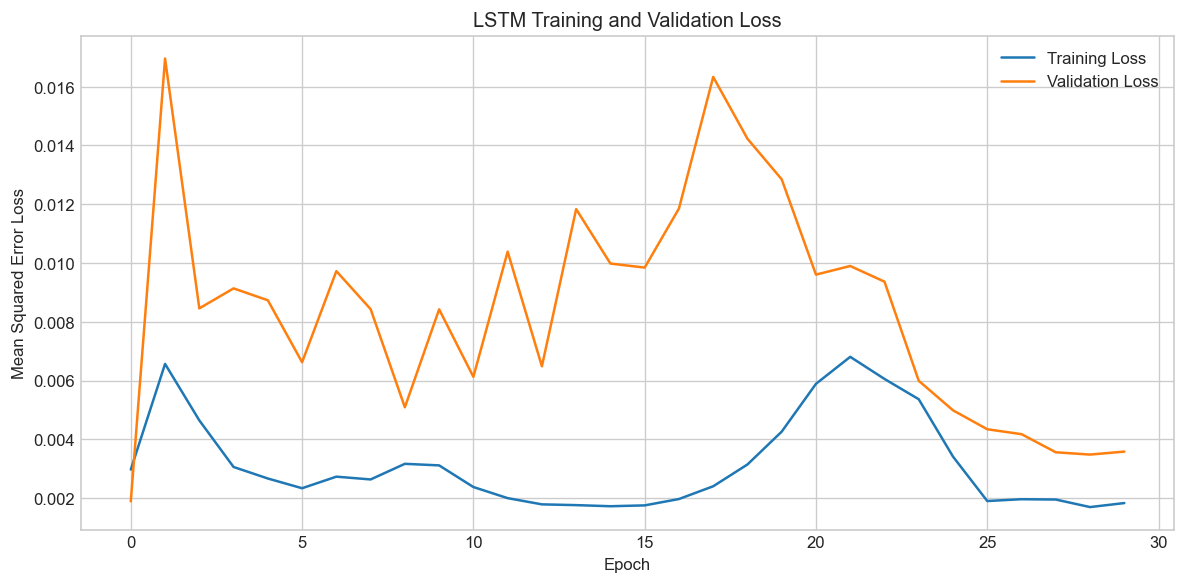

In [9]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    verbose=0
)

print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_04_training_validation_loss.png", dpi=150)
plt.show()

## 10. LSTM Prediction and Evaluation

The model predicts on the test set. Both predicted and actual values are inverse transformed back to the original stock price scale before evaluation. MAPE uses a small epsilon value to avoid division-by-zero risk.

In [10]:
lstm_predictions_scaled = lstm_model.predict(X_test, verbose=0)

y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
lstm_predictions_original = scaler.inverse_transform(lstm_predictions_scaled).ravel()


def calculate_metrics(actual, predicted, epsilon=1e-8):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / (actual + epsilon))) * 100
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "MAPE (%)": mape,
    }


lstm_metrics = calculate_metrics(y_test_original, lstm_predictions_original)
lstm_metrics_df = pd.DataFrame([lstm_metrics], index=["LSTM"])
display(lstm_metrics_df)

,MAE,RMSE,R2 Score,MAPE (%)
LSTM,36.697066,43.974043,-1.263758,15.761068


## 11. LSTM Visualization

The first graph compares actual AAPL closing prices with LSTM predicted prices. The second graph shows the prediction error over time.

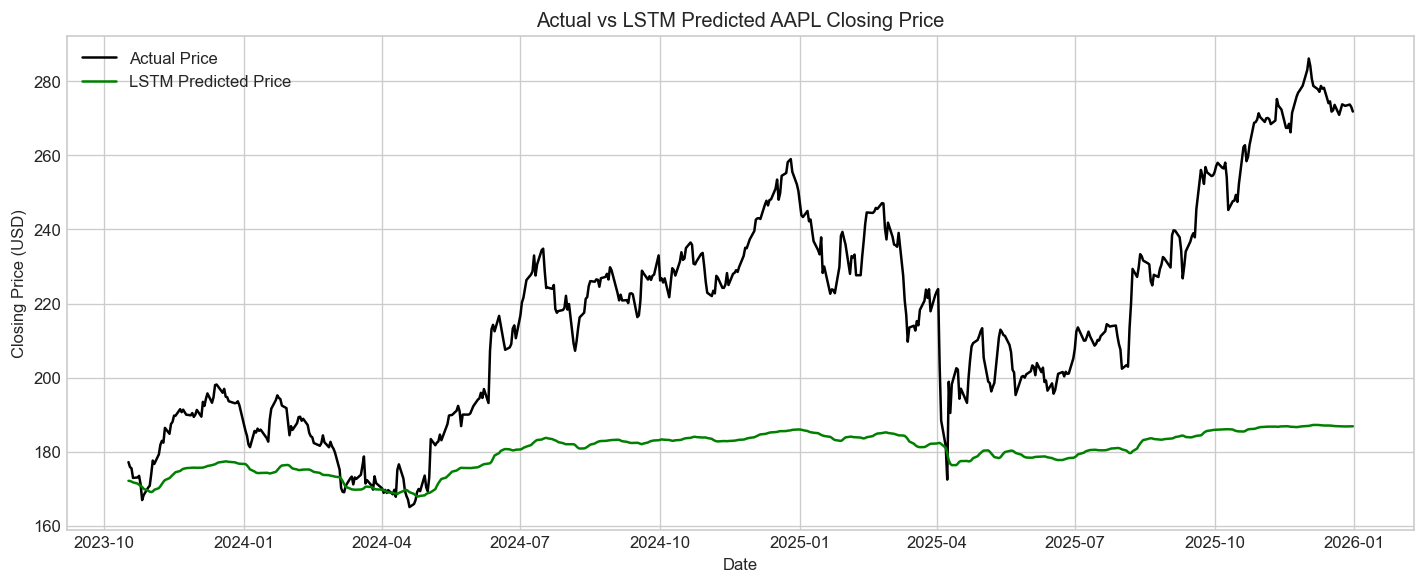

In [11]:
results_df = pd.DataFrame({
    "Date": test_dates,
    "Actual Price": y_test_original,
    "LSTM Predicted Price": lstm_predictions_original,
})
results_df["LSTM Error"] = results_df["Actual Price"] - results_df["LSTM Predicted Price"]
results_df["LSTM Absolute Error"] = results_df["LSTM Error"].abs()
results_df["LSTM Percentage Error (%)"] = (
    results_df["LSTM Absolute Error"] / (results_df["Actual Price"].abs() + 1e-8)
) * 100

plt.figure(figsize=(12, 5))
plt.plot(results_df["Date"], results_df["Actual Price"], label="Actual Price", color="black")
plt.plot(results_df["Date"], results_df["LSTM Predicted Price"], label="LSTM Predicted Price", color="green")
plt.title("Actual vs LSTM Predicted AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_05_lstm_actual_vs_predicted.png", dpi=150)
plt.show()

The actual-vs-predicted graph shows whether the LSTM model follows the general direction of Apple's closing price during the test period. A close match suggests stronger trend-following, while large gaps indicate prediction errors.

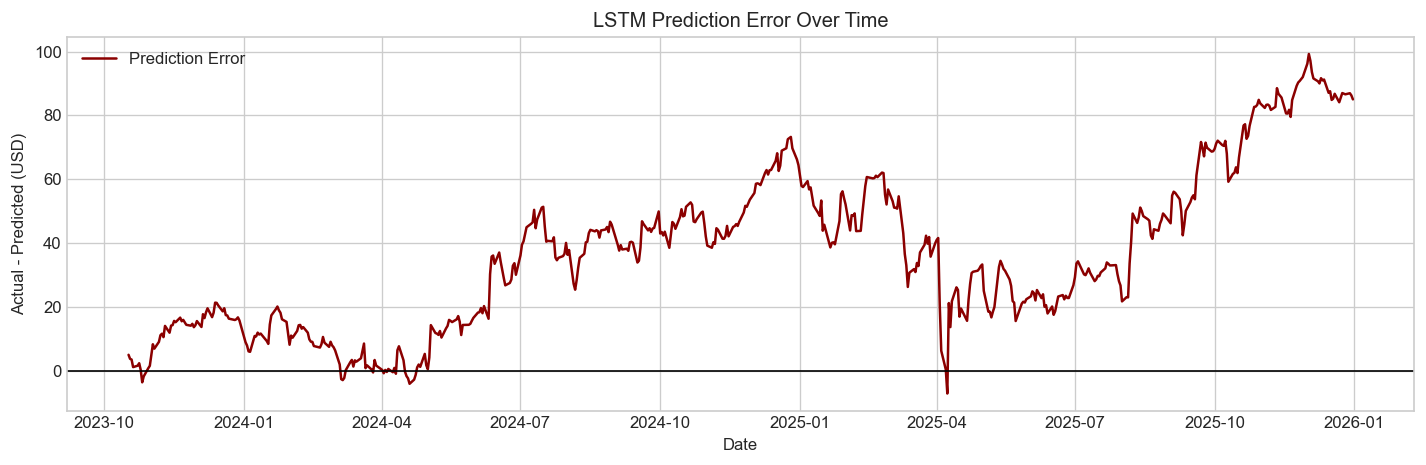

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(results_df["Date"], results_df["LSTM Error"], label="Prediction Error", color="darkred")
plt.axhline(0, color="black", linewidth=1)
plt.title("LSTM Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_06_lstm_prediction_error.png", dpi=150)
plt.show()

The error plot helps identify periods where the LSTM over-predicted or under-predicted Apple's closing price. Large spikes may occur during sharper market movements.

## 12. Sample Prediction Table

The table below shows sample test-set predictions with absolute and percentage error.

In [13]:
sample_predictions = results_df[
    [
        "Date",
        "Actual Price",
        "LSTM Predicted Price",
        "LSTM Absolute Error",
        "LSTM Percentage Error (%)",
    ]
]

display(sample_predictions.head(10))

,Date,Actual Price,LSTM Predicted Price,LSTM Absolute Error,LSTM Percentage Error (%)
0,2023-10-17,177.149994,172.088455,5.061539,2.857205
1,2023-10-18,175.839996,172.046829,3.793167,2.157170
2,2023-10-19,175.460007,171.885071,3.574936,2.037465
3,2023-10-20,172.880005,171.676208,1.203796,0.696319
4,2023-10-23,173.000000,171.349228,1.650772,0.954204
5,2023-10-24,173.440002,171.013733,2.426270,1.398910
6,2023-10-25,171.100006,170.754974,0.345032,0.201655
7,2023-10-26,166.889999,170.443817,3.553818,2.129437
8,2023-10-27,168.220001,169.913895,1.693893,1.006951
9,2023-10-30,170.289993,169.424896,0.865097,0.508014


## 13. Alternative Model Comparison

Random Forest Regressor is used as a traditional machine learning comparison model. The same 60-day sequence input is flattened into 2D features because Random Forest does not accept the 3D LSTM input format.

,MAE,RMSE,R2 Score,MAPE (%)
LSTM,36.697066,43.974043,-1.263758,15.761068
Random Forest,27.285858,36.604641,-0.568590,11.393788


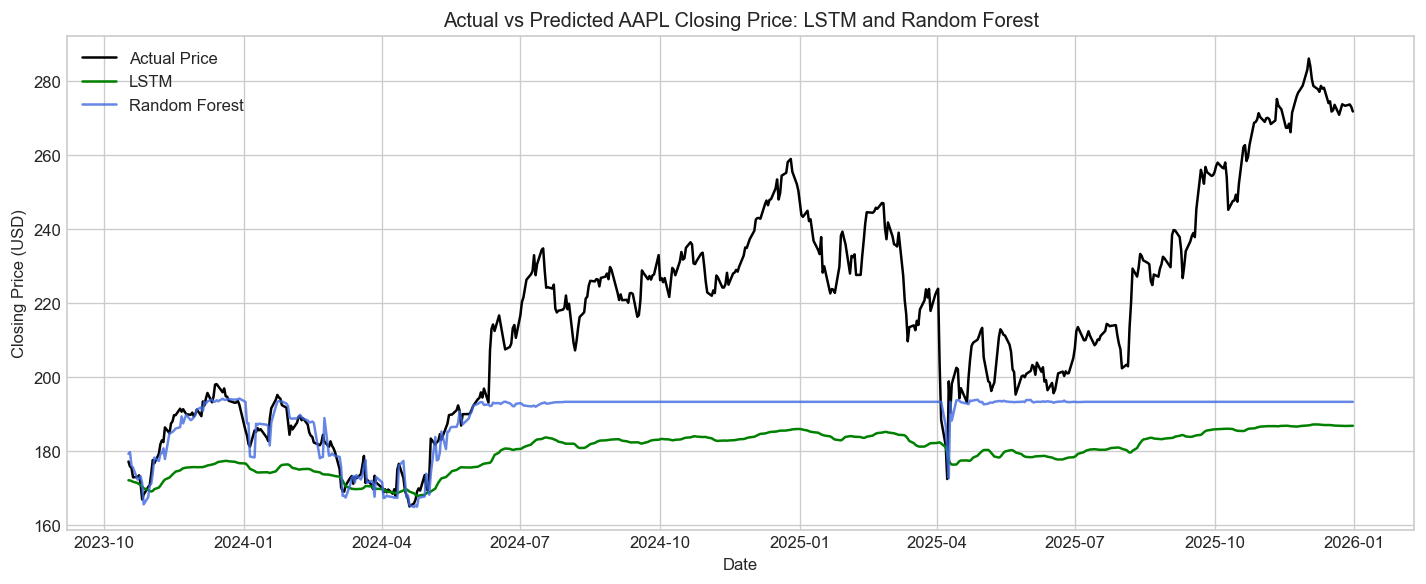

In [14]:
X_train_rf = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_rf = X_test.reshape(X_test.shape[0], X_test.shape[1])

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_SEED
)
rf_model.fit(X_train_rf, y_train)

rf_predictions_scaled = rf_model.predict(X_test_rf).reshape(-1, 1)
rf_predictions_original = scaler.inverse_transform(rf_predictions_scaled).ravel()

rf_metrics = calculate_metrics(y_test_original, rf_predictions_original)

comparison_df = pd.DataFrame(
    [lstm_metrics, rf_metrics],
    index=["LSTM", "Random Forest"]
)[["MAE", "RMSE", "R2 Score", "MAPE (%)"]]

display(comparison_df)

results_df["Random Forest Predicted Price"] = rf_predictions_original

plt.figure(figsize=(12, 5))
plt.plot(results_df["Date"], results_df["Actual Price"], label="Actual Price", color="black")
plt.plot(results_df["Date"], results_df["LSTM Predicted Price"], label="LSTM", color="green")
plt.plot(
    results_df["Date"],
    results_df["Random Forest Predicted Price"],
    label="Random Forest",
    color="royalblue",
    alpha=0.8,
)
plt.title("Actual vs Predicted AAPL Closing Price: LSTM and Random Forest")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_07_lstm_vs_random_forest.png", dpi=150)
plt.show()

## 14. Result Interpretation

Lower MAE, RMSE, and MAPE values indicate better prediction accuracy, while a higher R2 score indicates a better fit to the actual values. The comparison table should be used to decide whether LSTM or Random Forest performs better on this test set.

If Random Forest performs close to or better than LSTM, it does not mean the project failed. It shows that a simpler model can sometimes perform well when the feature set is limited to historical closing-price windows. A more complex deep learning model is not automatically better; it may need additional features or tuning to provide a clear advantage.

## Critical Analysis

### Strengths of LSTM

LSTM is suitable for sequential data because it processes ordered observations over time. It can learn time-dependent patterns from the previous 60 trading days and may capture general trend-following behaviour in Apple's historical stock price.

### Limitations

The model can overfit because stock data is noisy and the training data may contain patterns that do not repeat in the future. It also depends heavily on historical data, which means its predictions are limited by the information included in past prices.

The model is sensitive to market volatility and cannot directly predict sudden news, earnings surprises, economic events, interest rate changes, or investor sentiment. Since this notebook uses only closing price, it excludes many potentially useful predictors. The model may also lag during sudden reversals because it learns from previous price movements rather than future events.

### Comparison with Random Forest

The LSTM naturally models sequential patterns, while Random Forest is simpler, faster, and easier to train. However, Random Forest does not naturally understand time order unless sequence features are manually created, as done in this notebook by flattening the 60-day window.

This model should not be treated as a real trading system. Good prediction graphs do not guarantee profitable trading performance after risk, transaction costs, timing, and changing market conditions are considered.

## Conclusion

This project successfully implemented an LSTM-based Recurrent Neural Network model for Apple stock price prediction. The model can learn general historical price trends from sequential closing-price data and provides a useful educational example of time-series forecasting.

However, real stock prices depend on many external factors that are not included in this dataset. Therefore, the model should be treated as an educational forecasting model, not a real trading system.

Future improvements could include using Open, High, Low, Close, and Volume together, adding technical indicators such as moving averages, RSI, and MACD, adding sentiment analysis from financial news, adding macroeconomic features, comparing with GRU and Transformer models, and using walk-forward validation.

## Source Code Link

[Insert GitHub repository link here]